In [153]:
import numpy as np
import requests
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table, join, vstack
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.cluster import MeanShift       
from sklearn import preprocessing         

In [157]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [158]:
data

array([['GRB260910A', 'GRB260907B', 'GRB260907A*', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['None', 'GRB260907330', 'GRB260907019', ..., 'None', 'None',
        'None'],
       ['1:23:49', '7:55:22.686', '0:28:01.744', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['-999', '13.8240', '0.5760', ..., '3.1360', '208.5760', '5.6960'],
       ['True', 'True', 'True', ..., 'False', 'False', 'False'],
       ['61293.05820602', '61290.33012368', '61290.01946463', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      dtype='<U14')

In [159]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

### question we are trying to answer

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 

In [165]:
data_dict = dict(zip(names, data))
data_dict

{'GRB_name': array(['GRB260910A', 'GRB260907B', 'GRB260907A*', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'], dtype='<U14'),
 'GRB_name_Fermi': array(['None', 'GRB260907330', 'GRB260907019', ..., 'None', 'None',
        'None'], dtype='<U14'),
 'T0': array(['1:23:49', '7:55:22.686', '0:28:01.744', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'], dtype='<U14'),
 'ra': array(['210.1000', '327.5500', '22.3700', ..., '201.3000', '193.4750',
        '270.6750'], dtype='<U14'),
 'decl': array(['6.0000', '24.9100', '-39.0400', ..., '-45.4167', '-8.3833',
        '24.7667'], dtype='<U14'),
 'pos_error': array(['-999', '4.703141', '5.838820', ..., '13.780000', '11.100000',
        '0.530000'], dtype='<U14'),
 'T90': array(['-999', '13.8240', '0.5760', ..., '3.1360', '208.5760', '5.1840'],
       dtype='<U14'),
 'T90_error': array(['-999', '2.2900', '0.0910', ..., '0.5900', '1.1180', '0.1810'],
       dtype='<U14'),
 'T90_start': array(['-999', '7:55:22.686', '0:28:01.744

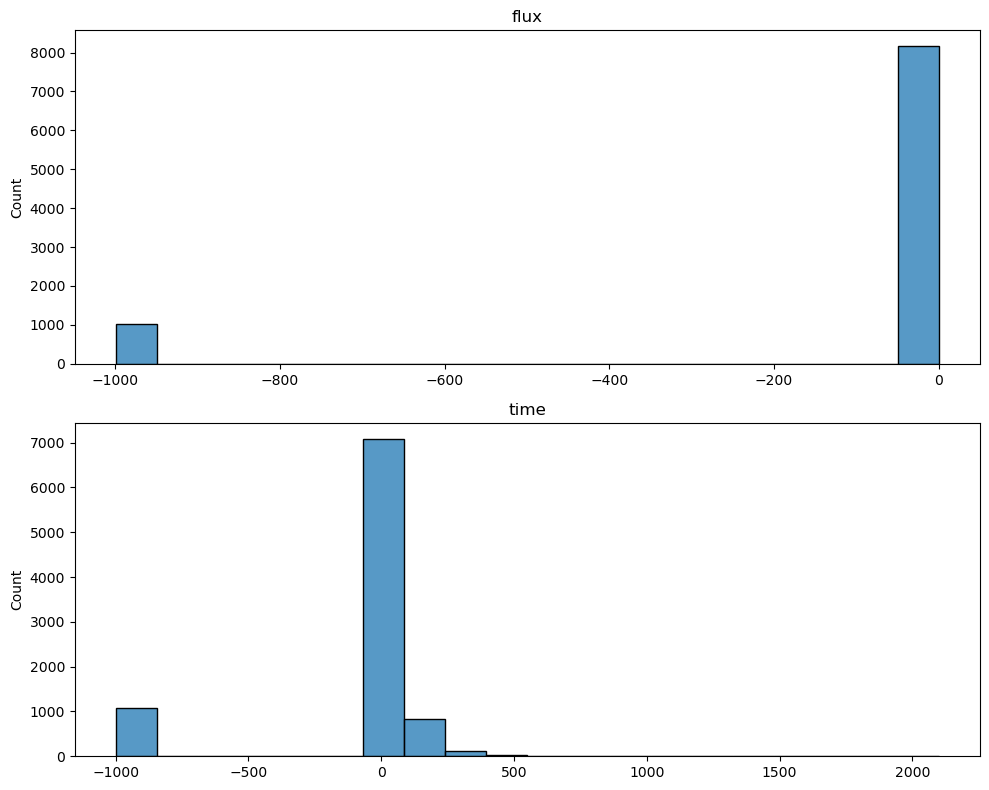

In [167]:
#preliminar analysis (without focusin on hist binning too much)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

sns.histplot(data_dict["fluence"].astype(np.float64), bins=20, ax=axs[0])
axs[0].set_title("flux")
sns.histplot(data_dict["T90"].astype(np.float64), bins=20, ax=axs[1])
axs[1].set_title("time")

plt.tight_layout()
plt.show()

In [169]:
flux_data = data_dict["fluence"].astype(np.float64)
time_data = data_dict["T90"].astype(np.float64)

In [171]:
#mask to avoid bad values
mask_flux = (flux_data != -999) 
mask_time = (time_data != -999)

flux = flux_data[mask_flux*mask_time]
time = time_data[mask_flux*mask_time]

In [173]:
print(len(flux))
print(len(time))

7981
7981


In [175]:
flux

array([1.9169e-06, 9.1093e-07, 1.0497e-06, ..., 2.4858e-08, 1.6510e-07,
       2.6055e-06])

In [177]:
time

array([ 13.824,   0.576,   5.376, ...,   3.136, 208.576,   5.184])

C:\Users\User\AppData\Local\Temp\ipykernel_33952\1895299995.py:3: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(np.log10(flux), bins=50, ax=axs[0])


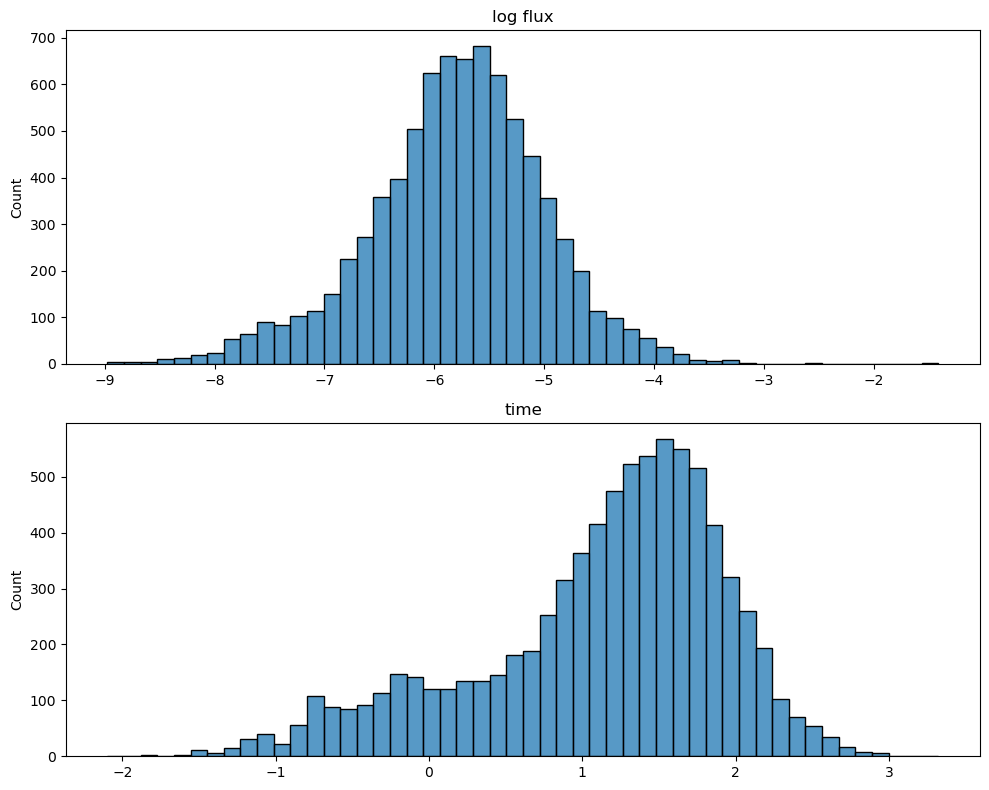

In [179]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

sns.histplot(np.log10(flux), bins=50, ax=axs[0])
axs[0].set_title("log flux")
sns.histplot(np.log10(time), bins=50, ax=axs[1])
axs[1].set_title("time")

plt.tight_layout()
plt.show()

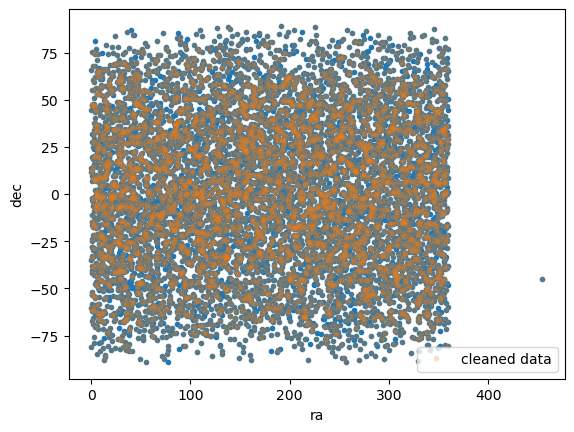

In [180]:
ra_data = data_dict["ra"].astype(np.float64)
dec_data = data_dict['decl'].astype(np.float64)
ra = ra_data[mask_flux*mask_time]
dec = dec_data[mask_flux*mask_time]

plt.plot(ra_data, dec_data,".")
plt.plot(ra, dec, ".", alpha=0.2, label="cleaned data")
plt.xlabel("ra")
plt.ylabel("dec")
plt.legend()

Text(0, 0.5, '$\\log(f)$')

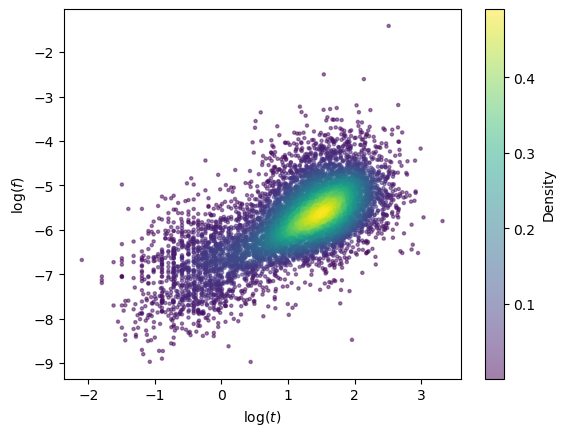

In [183]:
positive_value = (time > 0) & (flux > 0)

t_pos = time[positive_value]
flux_pos = flux[positive_value]

log_t = np.log10(t_pos)
log_flux = np.log10(flux_pos)

flux_T = np.vstack([log_t, log_flux])
z = gaussian_kde(flux_T)(flux_T)

sc= plt.scatter(log_t,log_flux, c=z, cmap="viridis", alpha=0.5, s=5)
plt.colorbar(sc,label='Density')
plt.xlabel(r"$\log(t)$")
plt.ylabel(r"$\log(f)$")

[[ 1.14063373 -5.71740054]
 [-0.23957752 -6.04051499]
 [ 0.73045926 -5.9789348 ]
 ...
 [ 0.49637605 -7.60453382]
 [ 2.31926433 -6.78225293]
 [ 0.71466499 -5.58410892]]


C:\Users\User\AppData\Local\Temp\ipykernel_33952\3626180881.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")


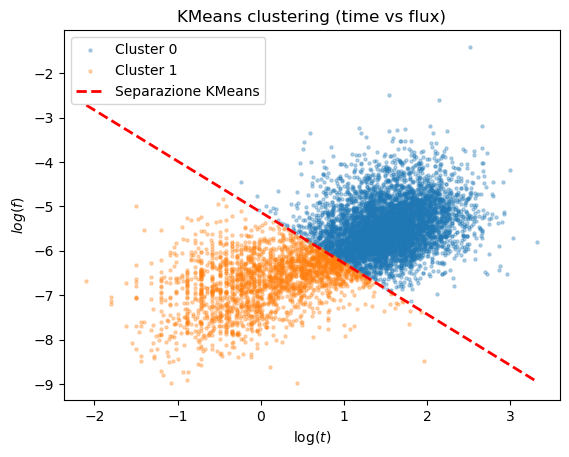

In [184]:
X = np.column_stack((log_t, log_flux))
print(X)
clf = KMeans(n_clusters=2, n_init='auto', random_state=0)
labels = clf.fit_predict(X)

colors = ['C0', 'C1']

plt.figure()

for ii in range(2):
    plt.scatter(log_t[labels == ii],
                log_flux[labels == ii],
                color=colors[ii],
                alpha=0.3, s=5,
                label=f'Cluster {ii}')


c0, c1 = clf.cluster_centers_ #they are two dimensional coordinate 
#calcolo della bisettrice 
w = c1 - c0
mid = (c0 + c1) / 2

a = w[0]
b = w[1]
c = -a * mid[0] - b * mid[1]

x_vals = np.linspace(log_t.min(), log_t.max(), 200)
y_vals = (-a * x_vals - c) / b
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")


plt.xlabel(r'$\log(t)$')
plt.ylabel(r'$log(f)$')
plt.title('KMeans clustering (time vs flux)')
plt.legend()

plt.show()

In [185]:
X = np.column_stack((log_t, log_flux))
scaler = preprocessing.StandardScaler()       

bandwidth = 0.4

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False, min_bin_freq=60)

X_new = ms.fit(scaler.fit_transform(X))
labels_ms = ms.predict(scaler.transform(X))
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print("number of estimated clusters :", n_clusters)

[-1  0  1]
number of estimated clusters : 2


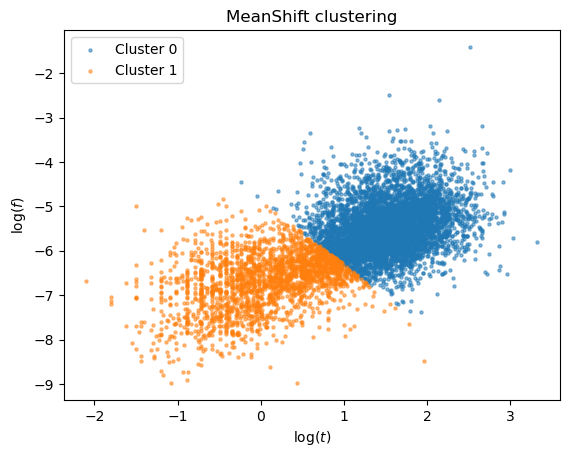

In [187]:
for ii in range(2):
    mask = labels_ms == ii
    
    plt.scatter(log_t[mask],log_flux[mask],alpha=0.5,s=5,label=f'Cluster {ii}')

plt.xlabel(r'$\log(t)$')
plt.ylabel(r'$\log(f)$')
plt.title('MeanShift clustering')
plt.legend()
plt.show()

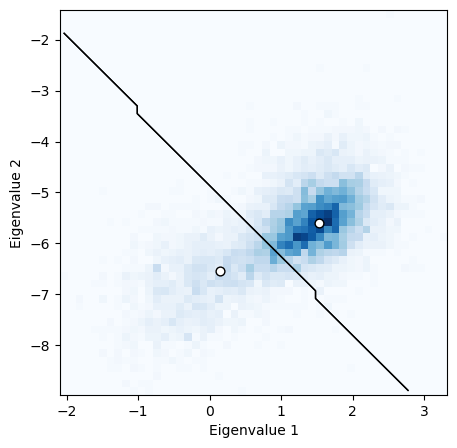

In [189]:
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2,50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

696


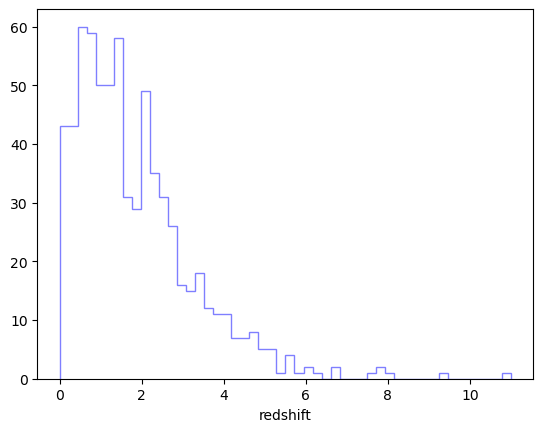

In [192]:
z_data = data_dict["redshift"].astype(np.float64)
mask_z = (z_data != -999) 
redshift = z_data[mask_z*mask_flux*mask_time]

plt.hist(redshift, bins=50, alpha=0.5, histtype="step", color="blue")
plt.xlabel("redshift") 
print(len(redshift))

696


Text(0, 0.5, 'z')

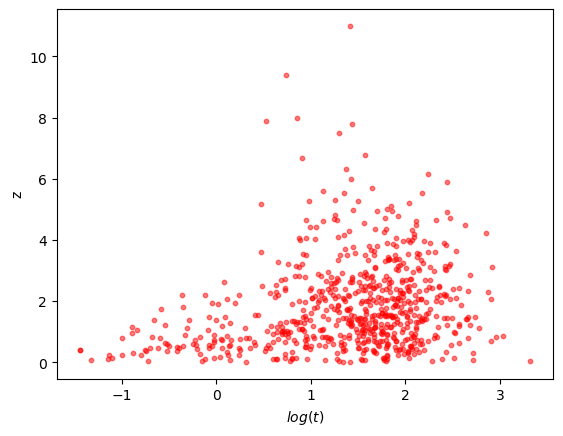

In [195]:
t_maskz = time_data[mask_z*mask_flux*mask_time]
flux_maskz = flux_data[mask_z*mask_flux*mask_time]

print(len(t_maskz))
plt.scatter(np.log10(t_maskz),redshift, s=10,alpha=0.5, color="red") 
plt.xlabel(r"$log(t)$")
plt.ylabel(r"z")

In [197]:
positive_value_maskz = ( redshift > 0) & (flux_maskz > 0)

z_pos = redshift[positive_value_maskz]
print(z_pos)
flux_pos_maskz = flux_maskz[positive_value_maskz]
log_flux_maskz = np.log10(flux_pos_maskz)

[5.5000e-02 4.7350e-01 1.1850e-01 2.0060e+00 2.1150e+00 1.5300e-01
 2.3600e+00 1.4340e+00 5.2400e-01 2.6230e+00 3.1710e+00 7.0450e-01
 1.1000e+00 2.7850e+00 1.5990e+00 3.5150e+00 7.6000e-01 5.5000e-02
 4.3335e+00 5.7200e-01 4.4120e+00 2.1780e+00 2.1620e+00 3.8990e+00
 1.3990e+00 2.2000e+00 1.1450e+00 2.0150e+00 1.7520e+00 1.5220e+00
 5.2600e+00 1.5200e+00 1.5200e+00 6.5500e-01 1.3960e+00 7.6700e-01
 3.1000e-01 1.3600e+00 2.6270e+00 1.8470e+00 2.8230e+00 4.2000e-01
 1.8980e+00 3.3150e+00 9.5000e-01 7.6800e-01 4.6100e+00 3.5500e+00
 2.1510e+00 4.7320e+00 2.1970e+00 4.0100e+00 2.4900e+00 2.6740e+00
 1.1370e+00 2.6810e+00 2.8200e+00 1.4110e+00 1.0720e+00 2.7900e+00
 4.2000e+00 9.7700e-01 2.6100e+00 1.2340e+00 1.4600e+00 6.5900e-01
 2.3800e-01 1.4950e+00 3.9650e-01 2.6950e+00 5.7900e-02 4.1600e-01
 5.1780e+00 1.8330e+00 6.7820e+00 1.5000e-01 8.2400e-01 6.8000e-01
 2.3050e+00 3.1300e+00 8.3040e-01 2.5700e-01 1.2845e+00 6.4700e-02
 2.4200e+00 3.6000e-01 3.7000e+00 1.4120e-01 3.5680e+00 9.0000

Text(0, 0.5, '$\\log(f)$')

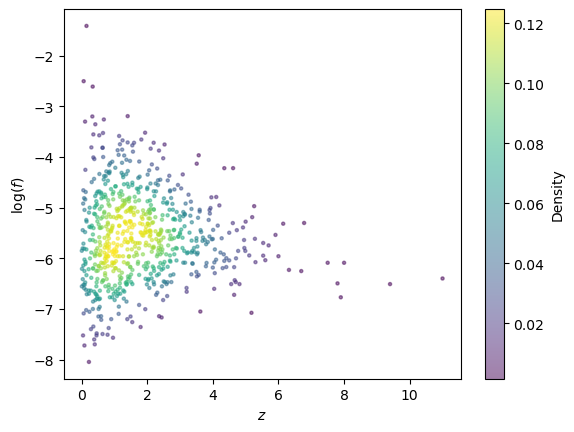

In [199]:
flux_T = np.vstack([z_pos, log_flux_maskz])
z_plot = gaussian_kde(flux_T)(flux_T)

sc= plt.scatter(z_pos, log_flux_maskz, c=z_plot, cmap="viridis", alpha=0.5, s=5)
plt.colorbar(sc,label='Density')
plt.xlabel(r"$z$")
plt.ylabel(r"$\log(f)$")

this is correct if we think about measurement: as the redshift increase we can detect less flux 

(-1500.0, 2000.0)

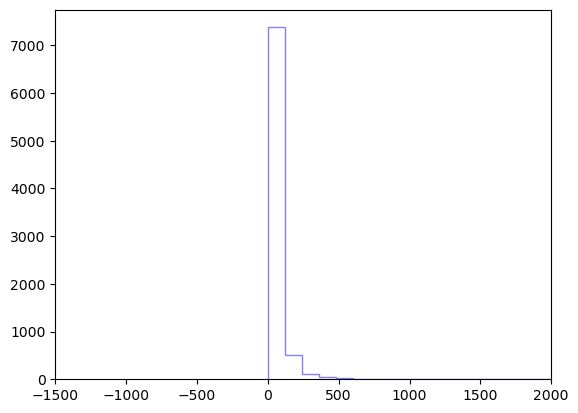

In [202]:
T100_data = data_dict["\'T100\'"].astype(np.float64)
plt.hist(T100, bins=100, alpha=0.5, histtype="step", color="blue")
plt.xlim(-1500, 2000)

Text(0.5, 0, '$\\log(T100)$')

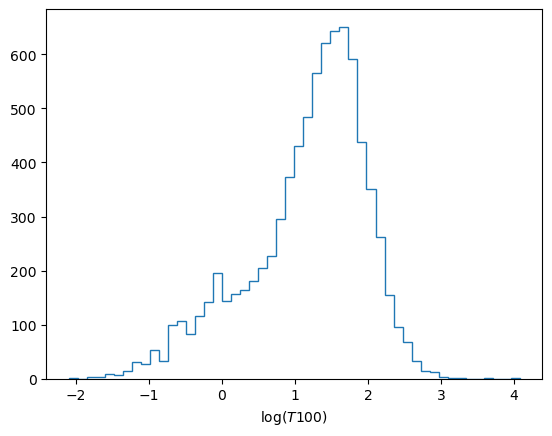

In [204]:
mask_T100 = (T100_data != -999)
T100 = T100_data[mask_T100]
plt.hist(np.log10(T100), bins=50, histtype="step")
plt.xlabel(r"$\log(T100)$")
#think another bimodality is found